In [1]:
import torch # imported before PyQt
from PyQt6.QtWidgets import QApplication

# Data preparation

In [2]:
import pandas as pd
data_path="./sms_spam_dataset/SMSSpamCollection.tsv"
df = pd.read_csv(data_path, sep="\t", names=["Label", "Text"])

df.head()

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5572, 2)

In [4]:
df["Label"].value_counts()

Label
ham     4825
spam     747
Name: count, dtype: int64

In [5]:
#balencing the lebel
num_spam = df[df["Label"]=="spam"].shape[0]

ham_subset = df[df["Label"]=="ham"].sample(num_spam, random_state=123)

balanced_df = pd.concat([ham_subset, df[df["Label"]=="spam"]])

balanced_df["Label"].value_counts()

Label
ham     747
spam    747
Name: count, dtype: int64

In [6]:
#encode into ham =0 and spam=1
balanced_df["Label"] =  balanced_df["Label"].map({"ham":0, "spam":1})

balanced_df["Label"].value_counts()

Label
0    747
1    747
Name: count, dtype: int64

In [7]:
#spliting of data into train,test
from sklearn.model_selection import train_test_split
#taking train 70% of data and 30% for validation and test in that 20%for test and 10% for validation 
train_df,temp=train_test_split(
  balanced_df,
  test_size=0.3,
  random_state=123,
  shuffle=True
)
valid_df,test_df=train_test_split(
  balanced_df,
  test_size=2/3,
  random_state=123,
  shuffle=True
)

In [8]:
train_df.shape,test_df.shape,valid_df.shape

((1045, 2), (996, 2), (498, 2))

## DataLoader

In [9]:
import torch
from PyQt6.QtWidgets import QApplication
import torch.nn as nn
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=None, pad_token_id=50256):
        self.data = df
        
        self.encoded_texts = [tokenizer.encode(text) for text in self.data["Text"]]
        
        if max_length is None:
            self.max_length = self.__longest_encoded_length()
        else:
            self.max_length = max_length
            #TRUNCATION
            self.encoded_texts = [encoded_text[:self.max_length] for encoded_text in self.encoded_texts]
        
        #PADDING
        self.encoded_texts = [encoded_text+[pad_token_id]*(self.max_length-len(encoded_text)) for encoded_text in self.encoded_texts]
    
    def __longest_encoded_length(self):
        maxlen = 0
        for encoded_text in self.encoded_texts:
            encoded_len = len(encoded_text)
            if encoded_len > maxlen:
                maxlen = encoded_len
        return maxlen
    
    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return(
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )
        
    def __len__(self):
        return len(self.data)
        

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=None, pad_token_id=50256):
        self.df = df
        self.encoded_texts = [tokenizer.encode(text) for text in self.df["Text"]]

        if max_length is None:
            self.max_length = self.__get_max_len()
        else:
            self.max_length = max_length
            self.encoded_texts = [
                encoded_text[:self.max_length] for encoded_text in self.encoded_texts
            ]

        # padding
        self.encoded_texts = [
            encoded_text + [pad_token_id] * (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]

    def __get_max_len(self):
        maxlen = 0
        for encoded_text in self.encoded_texts:
            if len(encoded_text) > maxlen:
                maxlen = len(encoded_text)
        return maxlen

    def __getitem__(self, index):
        encoded_text = self.encoded_texts[index]
        label = self.df.iloc[index]["Label"]

        return (
            torch.tensor(encoded_text, dtype=torch.long),
            torch.tensor(label, dtype=torch.long),
        )

    def __len__(self):
        return len(self.df)

In [11]:
import tiktoken
tokenizer=tiktoken.get_encoding("gpt2")

In [12]:
train_dataset=SpamDataset(
  df=train_df,
  tokenizer=tokenizer,
  max_length=None,
)
valid_dataset=SpamDataset(
  df=valid_df,
  tokenizer=tokenizer,
  max_length=None,
)
test_dataset=SpamDataset(
  df=test_df,
  tokenizer=tokenizer,
  max_length=None,
)


In [13]:
from torch.utils.data import DataLoader
num_worker=0
batch_size=8
torch.manual_seed(123)

#shuffing of data make input output
train_loader=DataLoader(
 dataset=train_dataset,
 batch_size=batch_size,
 shuffle=True,
 num_workers= num_worker,
 drop_last=True
)

val_loader=DataLoader(
 dataset=valid_dataset,
 batch_size=batch_size,
 shuffle=True,
 num_workers= num_worker,
 drop_last=True
)

test_loader=DataLoader(
 dataset=test_dataset,
 batch_size=batch_size,
 shuffle=True,
 num_workers= num_worker,
 drop_last=True
)

In [14]:
#print differnt shape
print("TRAIN-LOADER")

for input_batch, output_batch in train_loader:
    pass

print("TRAIN-LOADER-SIZE", len(train_loader))
print("INPUT-BATCH: ", input_batch.shape)
print("OUTPUT-BATCH: ", output_batch.shape)

print("\n\nTEST-LOADER")

for input_batch, output_batch in test_loader:
    pass

print("TEST-LOADER-SIZE", len(train_loader))
print("INPUT-BATCH: ", input_batch.shape)
print("OUTPUT-BATCH: ", output_batch.shape)

print("\n\nVAL-LOADER")

for input_batch, output_batch in val_loader:
    pass

print("VAL-LOADER-SIZE", len(val_loader))
print("INPUT-BATCH: ", input_batch.shape)
print("OUTPUT-BATCH: ", output_batch.shape)

TRAIN-LOADER
TRAIN-LOADER-SIZE 130
INPUT-BATCH:  torch.Size([8, 104])
OUTPUT-BATCH:  torch.Size([8])


TEST-LOADER
TEST-LOADER-SIZE 130
INPUT-BATCH:  torch.Size([8, 120])
OUTPUT-BATCH:  torch.Size([8])


VAL-LOADER
VAL-LOADER-SIZE 62
INPUT-BATCH:  torch.Size([8, 92])
OUTPUT-BATCH:  torch.Size([8])


# Fine Tuning Part Started

# Generate next word

In [15]:
from GPT_Model import *
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 1024,
    "emb_dim": 768,
    "n_heads": 12,
    "n_layers": 12,
    "drop_rate": 0.0,       # set to 0 for inference
    "qkv_bias": True        # GPT-2 uses bias
}

In [16]:
from safetensors.torch import load_file
import json

# Load the weights
weights = load_file(r"D:\Projects\IMPOLS\pretrained_models\gpt2\model.safetensors")
#load config
with open(r"D:\Projects\IMPOLS\pretrained_models\gpt2\config.json") as f:
    hf_config = json.load(f)


def assign(left, right):
    if left.shape != right.shape:
        raise ValueError(f"Shape mismatch → Left: {left.shape}, Right: {right.shape}")
    return nn.Parameter(right.clone().detach().float())

def load_hf_into_my_gpt(model, w):
    model.token_emb.weight = assign(model.token_emb.weight, w["wte.weight"])
    model.pos_emb.weight   = assign(model.pos_emb.weight,   w["wpe.weight"])

    for b in range(cfg["n_layer"]):
        p  = f"h.{b}"
        tb = model.tranformer_block[b]

        # LayerNorms
        tb.layernorm1.scale = assign(tb.layernorm1.scale, w[f"{p}.ln_1.weight"])
        tb.layernorm1.shift = assign(tb.layernorm1.shift, w[f"{p}.ln_1.bias"])
        tb.layernorm2.scale = assign(tb.layernorm2.scale, w[f"{p}.ln_2.weight"])
        tb.layernorm2.shift = assign(tb.layernorm2.shift, w[f"{p}.ln_2.bias"])

        # Q, K, V (split from concatenated HuggingFace format)
        qkv_w = w[f"{p}.attn.c_attn.weight"]  # [768, 2304]
        qkv_b = w[f"{p}.attn.c_attn.bias"]    # [2304]
        q_w, k_w, v_w = torch.split(qkv_w, 768, dim=1)
        q_b, k_b, v_b = torch.split(qkv_b, 768, dim=0)

        tb.mutihead_atten.w_query.weight = assign(tb.mutihead_atten.w_query.weight, q_w.T)
        tb.mutihead_atten.w_key.weight   = assign(tb.mutihead_atten.w_key.weight,   k_w.T)
        tb.mutihead_atten.w_value.weight = assign(tb.mutihead_atten.w_value.weight, v_w.T)
        tb.mutihead_atten.w_query.bias   = assign(tb.mutihead_atten.w_query.bias,   q_b)
        tb.mutihead_atten.w_key.bias     = assign(tb.mutihead_atten.w_key.bias,     k_b)
        tb.mutihead_atten.w_value.bias   = assign(tb.mutihead_atten.w_value.bias,   v_b)

        # Attention output projection
        tb.mutihead_atten.out_proj.weight = assign(
            tb.mutihead_atten.out_proj.weight, w[f"{p}.attn.c_proj.weight"].T)
        tb.mutihead_atten.out_proj.bias   = assign(
            tb.mutihead_atten.out_proj.bias,   w[f"{p}.attn.c_proj.bias"])

        # FeedForward
        tb.feed_forward.layer[0].weight = assign(
            tb.feed_forward.layer[0].weight, w[f"{p}.mlp.c_fc.weight"].T)
        tb.feed_forward.layer[0].bias   = assign(
            tb.feed_forward.layer[0].bias,   w[f"{p}.mlp.c_fc.bias"])
        tb.feed_forward.layer[2].weight = assign(
            tb.feed_forward.layer[2].weight, w[f"{p}.mlp.c_proj.weight"].T)
        tb.feed_forward.layer[2].bias   = assign(
            tb.feed_forward.layer[2].bias,   w[f"{p}.mlp.c_proj.bias"])

    # Final LayerNorm
    model.final_norm.scale = assign(model.final_norm.scale, w["ln_f.weight"])
    model.final_norm.shift = assign(model.final_norm.shift, w["ln_f.bias"])

    # Output head (weight tying)
    model.out_head.weight  = assign(model.out_head.weight,  w["wte.weight"])

    print("✅ Weights loaded successfully!")

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

gpt_model = GPT(cfg)        # must recreate after fixing cfg!
gpt_model.eval()

load_hf_into_my_gpt(gpt_model, weights)
gpt_model.to(device)

✅ Weights loaded successfully!


GPT(
  (token_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (tranformer_block): Sequential(
    (0): Transfomers(
      (layernorm1): LayerNorm()
      (layernorm2): LayerNorm()
      (mutihead_atten): MultiHeadAttention(
        (w_query): Linear(in_features=768, out_features=768, bias=True)
        (w_key): Linear(in_features=768, out_features=768, bias=True)
        (w_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (feed_forward): FeedForward(
        (layer): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): Transfomers(
      (layernorm1): LayerNorm()
      (layernorm2): Laye

In [18]:
def predict(gpt_model=gpt_model,prompt="",next_new_token=5,temp=.7,topk=4):
  #temp+topk implemention to find next token generation
  tokenid=generate_text(
    model=gpt_model,
    ip_token_id = torch.tensor(tokenizer.encode(prompt)).unsqueeze(0).to(device),
    max_new_tokens=next_new_token,
    context_size=int(cfg["context_len"]/4),
    temp=temp,
    topk=topk
  )
  return (token_id_to_text(tokenid,tokenizer))
prompt="My name is Trump what is your name"
predict(prompt=prompt,next_new_token=40,temp=.3,topk=3)  

["My name is Trump what is your name? I'm not your name. I'm not your name. I'm not your name. I'm not your name. I'm not your name. I'm not your name. I'm not"]

# Fine Tuning

In [19]:
#model intializattion
gpt_model

GPT(
  (token_emb): Embedding(50257, 768)
  (pos_emb): Embedding(1024, 768)
  (dropout): Dropout(p=0.1, inplace=False)
  (tranformer_block): Sequential(
    (0): Transfomers(
      (layernorm1): LayerNorm()
      (layernorm2): LayerNorm()
      (mutihead_atten): MultiHeadAttention(
        (w_query): Linear(in_features=768, out_features=768, bias=True)
        (w_key): Linear(in_features=768, out_features=768, bias=True)
        (w_value): Linear(in_features=768, out_features=768, bias=True)
        (out_proj): Linear(in_features=768, out_features=768, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (dropout): Dropout(p=0.1, inplace=False)
      (feed_forward): FeedForward(
        (layer): Sequential(
          (0): Linear(in_features=768, out_features=3072, bias=True)
          (1): GELU()
          (2): Linear(in_features=3072, out_features=768, bias=True)
        )
      )
    )
    (1): Transfomers(
      (layernorm1): LayerNorm()
      (layernorm2): Laye

In [20]:
for parm in gpt_model.parameters():
  parm.requires_grad=False

In [21]:
#change final ouptut layer to 2 as it binary classification problem
torch.manual_seed(123)
num_classes=2
gpt_model.out_head=torch.nn.Linear(
  in_features=GPT_CONFIG_124M["emb_dim"],
  out_features=num_classes
)

In [22]:
#for better training i make true the last transfomer block and last layer norm
for parm in gpt_model.tranformer_block[-1].parameters():
  parm.requires_grad=True
for parm in gpt_model.final_norm.parameters():
  parm.requires_grad=True  

#for full fine tuning
# for param in model.parameters(): 
#     param.requires_grad = True  

In [23]:
# set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# move model to device
gpt_model = gpt_model.to(device)
gpt_model.eval()  # important for inference

# encode input text
input_ids = tokenizer.encode("Do you have time")

# convert to tensor + add batch dimension + move to device
inputs = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)

# print input info
print("Inputs:", inputs)
print("Inputs shape:", inputs.shape)
print("Input device:", inputs.device)

# forward pass (no gradients needed)
with torch.no_grad():
    outputs = gpt_model(inputs)

# print output info
print("Outputs:\n", outputs)
print("Outputs shape:", outputs.shape)
print("Output device:", outputs.device)

Inputs: tensor([[5211,  345,  423,  640]], device='cuda:0')
Inputs shape: torch.Size([1, 4])
Input device: cuda:0
Outputs:
 tensor([[[-1.5854,  0.9904],
         [-3.7235,  7.4548],
         [-2.2661,  6.6049],
         [-3.5983,  3.9902]]], device='cuda:0')
Outputs shape: torch.Size([1, 4, 2])
Output device: cuda:0


In [24]:
#now output is in the last class 
#last token
print(outputs[:,-1,:] )

#now apply class leble by converting to probality(by softmax) we directly taken argmax in logit also for using softmax is for explainibilty
prob=torch.softmax(outputs[:,-1,:],dim=1)
label=torch.argmax(prob)
print(f"Class label:",label.item())


tensor([[-3.5983,  3.9902]], device='cuda:0')
Class label: 1


In [25]:
#calculating the classification accuracy
def calc_accuracy_loader(dataloader,model,device,num_batches=None):
  model.eval()
  correct_prediction,num_examples=0,0
  
  if num_batches is None:
    num_batches=len(dataloader)
  else:
    num_batches=min(num_batches,len(dataloader))

  for i ,(input_batch,target_batch) in enumerate(dataloader):
    if i < num_batches:
      input_batch=input_batch.to(device)
      target_batch=target_batch.to(device)

      with torch.no_grad():
        logits=gpt_model(input_batch)[:,-1,:]
      prob=torch.softmax(logits,dim=1)
      predicted_labels=torch.argmax(prob,dim=-1)
      
      num_examples+=predicted_labels.shape[0]
      correct_prediction+=(predicted_labels==target_batch).sum().item()
    else:
      break
  return correct_prediction/num_examples    


In [26]:
import torch
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
gpt_model.to(device)
torch.manual_seed(123)
train_acc=calc_accuracy_loader(train_loader,gpt_model,device,num_batches=10)
val_acc=calc_accuracy_loader(val_loader,gpt_model,device,num_batches=10)
test_acc=calc_accuracy_loader(test_loader,gpt_model,device,num_batches=10)

print("Training Accuracy: ", train_acc)
print("Test Accuracy: ", test_acc)
print("Val Accuracy: ", val_acc)

cuda
Training Accuracy:  0.5375
Test Accuracy:  0.475
Val Accuracy:  0.4875


In [27]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch = input_batch.to(device)
    target_batch = target_batch.to(device)
    
    # logits = model(input_batch).logits[:,-1,:]
    logits = model(input_batch).mean(dim=1)

    loss = torch.nn.functional.cross_entropy(logits, target_batch)
    
    return loss

In [28]:
def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        num_batches = min(num_batches, len(data_loader))
        
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i<num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss+=loss.item()
            
        else:
            break
    
    return total_loss/num_batches

In [29]:
with torch.no_grad():
    train_acc = calc_accuracy_loader(train_loader, gpt_model, device, num_batches=10)
    val_acc = calc_accuracy_loader(val_loader, gpt_model, device, num_batches=10)
    test_acc = calc_accuracy_loader(test_loader, gpt_model, device, num_batches=10)

print("Training Accuracy: ", train_acc)
print("Test Accuracy: ", test_acc)
print("Val Accuracy: ", val_acc)

Training Accuracy:  0.5375
Test Accuracy:  0.4875
Val Accuracy:  0.5375


# finetune model

In [30]:
def evaluate_model(model,train_loader,val_loader,device,eval_iter):
  model.eval()
  with torch.no_grad():
    trainloss=calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
    trainloss=calc_loss_loader(train_loader,model,device,num_batches=eval_iter)
  model.train()
  return trainloss,trainloss  

In [31]:
from tqdm import tqdm

In [32]:
def train_classifier_simple(model,train_loader,val_loader,optimizer,device,num_epochs,eval_freq,eval_iter,verbose=False):
  train_losses,val_losses,train_accs,val_accs=[],[],[],[]
  example_seen,global_step=0,-1
  epoch_iter=(range(num_epochs) if verbose else tqdm(range(num_epochs),desc="Training Epochs",leave=True)) #for progress bar tqdm uses
  for epoch in epoch_iter:
    if verbose:
      print("######################################")
      model.train()
      for input_batch,target_batch in train_loader:
        optimizer.zero_grad()
        loss=calc_loss_batch(input_batch,target_batch,model,device)
        loss.backward()
        optimizer.step()
        
        example_seen+=input_batch.shape[0]
        global_step += 1
        if global_step%eval_freq==0:
          train_loss,valloss=evaluate_model(model,train_loader,val_loader,device,eval_iter)
          train_losses.append(train_loss)
          val_losses.append(valloss)
          # if verbose:
          print(
                    f"Epoch: {epoch + 1} (Step: {global_step:06d}): "
                    f"TRAIN-LOSS={train_loss:.3f}, VAL-LOSS:{valloss:.3f}"
                  )
          train_acc=calc_accuracy_loader(train_loader,model,device=device,num_batches=eval_iter)  
          val_acc=calc_accuracy_loader(val_loader,model,device=device,num_batches=eval_iter)        
          # if verbose:
          print(f"Training Accuracy: {train_acc * 100:.2f}% | ", end="")
          print(f"Validation Accuracy: {val_acc * 100:.2f}%")
          train_accs.append(train_acc)
          val_accs.append(val_acc)
  return train_losses,val_losses,train_accs,val_accs,  example_seen      

In [33]:
import time
start_time=time.time()
torch.manual_seed(123)
optimizer=torch.optim.AdamW(gpt_model.parameters(),lr=5e-5,weight_decay=1e-3)
epochs=5
eval_freq=50
eval_iter=5#batch size
verbose=True
train_losses,val_losses,train_accs,val_accs,  example_seen =train_classifier_simple(
  gpt_model,
   train_loader=train_loader, 
    val_loader=val_loader,
    optimizer=optimizer,
    device=device,
    num_epochs=epochs,
    eval_freq=eval_freq,
    eval_iter=eval_iter,
    verbose=verbose
)
end_time=time.time()
print(f"Training Complete in {(end_time-start_time)/60} min")

######################################
Epoch: 1 (Step: 000000): TRAIN-LOSS=2.610, VAL-LOSS:2.610
Training Accuracy: 52.50% | Validation Accuracy: 42.50%
Epoch: 1 (Step: 000050): TRAIN-LOSS=0.574, VAL-LOSS:0.574
Training Accuracy: 42.50% | Validation Accuracy: 45.00%
Epoch: 1 (Step: 000100): TRAIN-LOSS=0.462, VAL-LOSS:0.462
Training Accuracy: 52.50% | Validation Accuracy: 42.50%
######################################
Epoch: 2 (Step: 000150): TRAIN-LOSS=0.273, VAL-LOSS:0.273
Training Accuracy: 55.00% | Validation Accuracy: 42.50%
Epoch: 2 (Step: 000200): TRAIN-LOSS=0.436, VAL-LOSS:0.436
Training Accuracy: 42.50% | Validation Accuracy: 55.00%
Epoch: 2 (Step: 000250): TRAIN-LOSS=0.273, VAL-LOSS:0.273
Training Accuracy: 50.00% | Validation Accuracy: 67.50%
######################################
Epoch: 3 (Step: 000300): TRAIN-LOSS=0.258, VAL-LOSS:0.258
Training Accuracy: 62.50% | Validation Accuracy: 45.00%
Epoch: 3 (Step: 000350): TRAIN-LOSS=0.253, VAL-LOSS:0.253
Training Accuracy: 62.50% |

In [57]:
#save the mode after classification fine tune
torch.save(gpt_model.state_dict(), " classification_fine_tune.pth")

In [34]:
import matplotlib.pyplot as plt

def plotvalues(epochs_seen, examples_seen, train_values, val_values, label="loss"):
        fig, ax1 = plt.subplots(figsize=(5, 3))
        
        ax1.plot(epochs_seen, train_losses, label=f"Training {label}")
        ax1.plot(epochs_seen, val_losses, linestyle="-.", label=f"Validation {label}")
        ax1.set_xlabel("Epochs")
        ax1.set_ylabel(label.capitalize())
        ax1.legend(loc="upper right")
        
        ax2 = ax1.twiny()
        ax2.plot(examples_seen, train_values, alpha=0)
        ax2.set_xlabel("Examples seen")
        
        fig.tight_layout()
        plt.show()

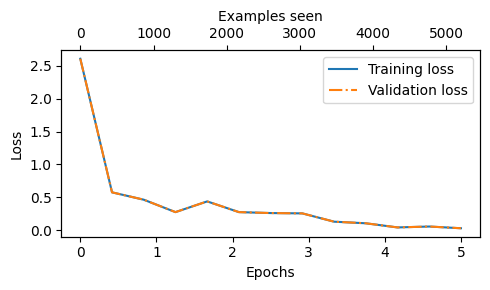

In [35]:
epochs_tensor=torch.linspace(0,epochs,len(train_losses))
example_seen_tensor=torch.linspace(0,example_seen,len(train_losses))
plotvalues(epochs_tensor,example_seen_tensor,train_losses,val_losses)

In [36]:
with torch.no_grad():
    train_acc = calc_accuracy_loader(train_loader, gpt_model, device, num_batches=10)
    val_acc = calc_accuracy_loader(val_loader, gpt_model, device, num_batches=10)
    test_acc = calc_accuracy_loader(test_loader, gpt_model, device, num_batches=10)

print("Training Accuracy: ", train_acc)
print("Test Accuracy: ", test_acc)
print("Val Accuracy: ", val_acc)

Training Accuracy:  0.5875
Test Accuracy:  0.5
Val Accuracy:  0.6375


# Testing on Unseen Data

In [54]:
def classify_review(text, model, tokenizer, device, max_len=None):
    model.eval()

    # encode using tiktoken
    input_ids = tokenizer.encode(text)

    # truncate if needed
    if max_len is not None:
        input_ids = input_ids[:max_len]

    # padding (same as dataset)
    if max_len is not None:
        pad_token_id = 50256  # GPT-2 pad token
        input_ids = input_ids + [pad_token_id] * (max_len - len(input_ids))

    # convert to tensor
    inputs = torch.tensor(input_ids, dtype=torch.long).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(inputs)
        logits = logits.mean(dim=1)

    predicted_label = torch.argmax(logits, dim=-1).item()

    return "spam" if predicted_label == 1 else "not spam"

In [55]:
text="You get hundred percent reward"
classify_review(text,gpt_model,tokenizer,device,max_len=train_dataset.max_length)

'not spam'